#**Gradient booster classifier**

Fold 1 Metrics:
  Accuracy: 0.7895
  Precision: 0.7957
  Recall: 0.7895
  F1-Score: 0.7895
Fold 2 Metrics:
  Accuracy: 0.7368
  Precision: 0.7478
  Recall: 0.7368
  F1-Score: 0.7395
Fold 3 Metrics:
  Accuracy: 0.8947
  Precision: 0.8947
  Recall: 0.8947
  F1-Score: 0.8947
Fold 4 Metrics:
  Accuracy: 0.8421
  Precision: 0.8655
  Recall: 0.8421
  F1-Score: 0.8382
Fold 5 Metrics:
  Accuracy: 0.7778
  Precision: 0.7825
  Recall: 0.7778
  F1-Score: 0.7766

Average Metrics Across All Folds:
  Accuracy: 0.8082
  Precision: 0.8173
  Recall: 0.8082
  F1-Score: 0.8077


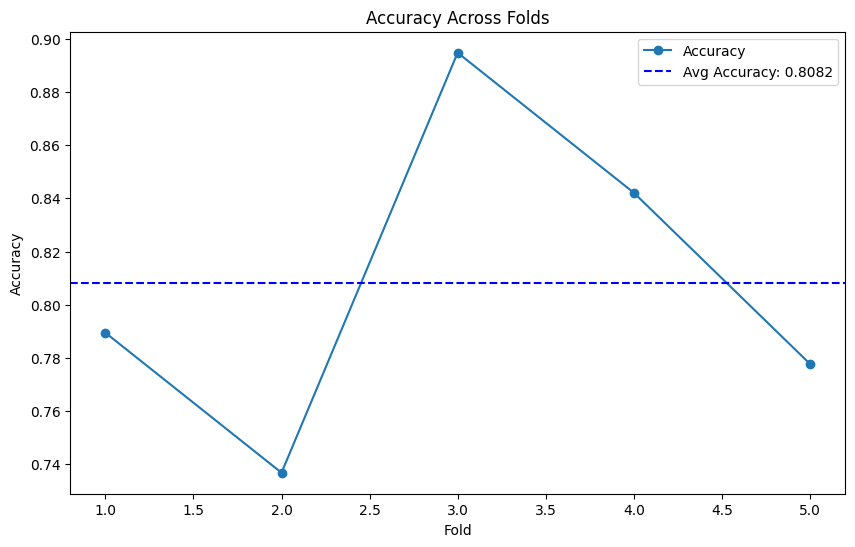

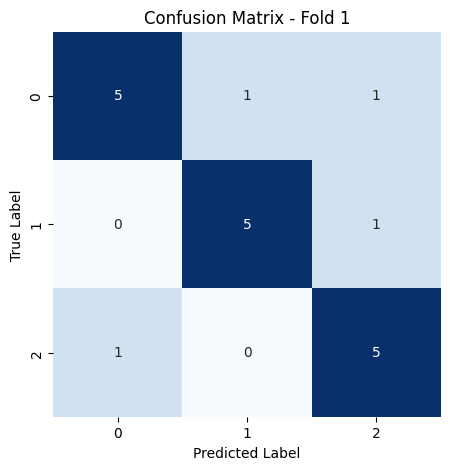

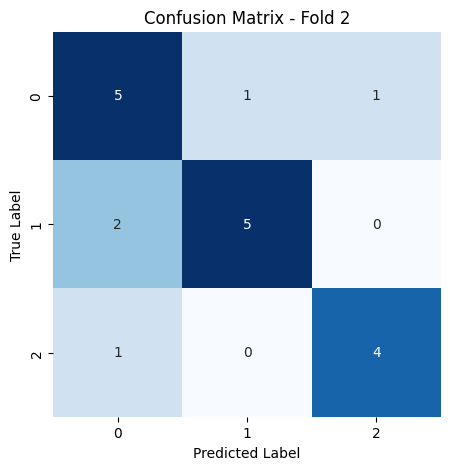

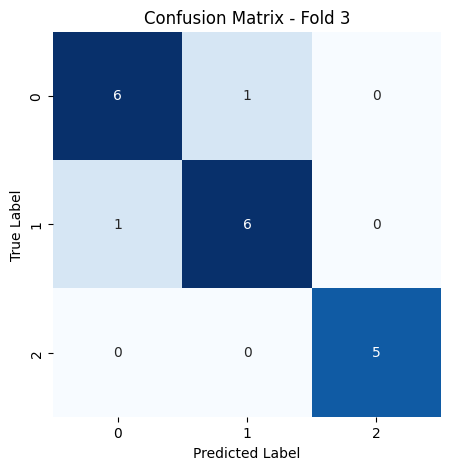

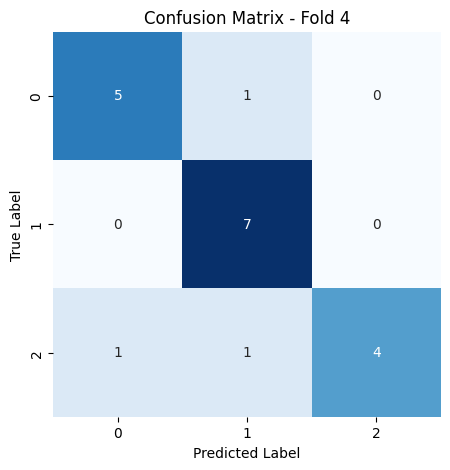

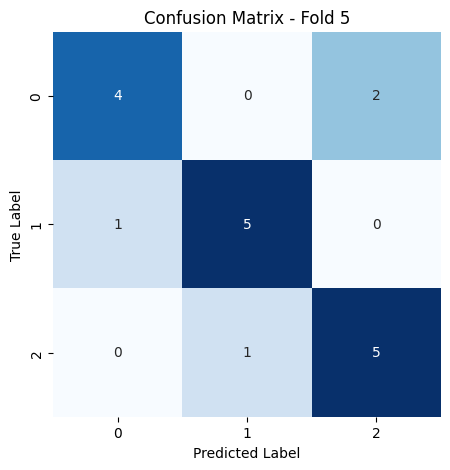


Test Set Metrics:
  Accuracy: 0.6667
  Precision: 0.6910
  Recall: 0.6667
  F1-Score: 0.6676


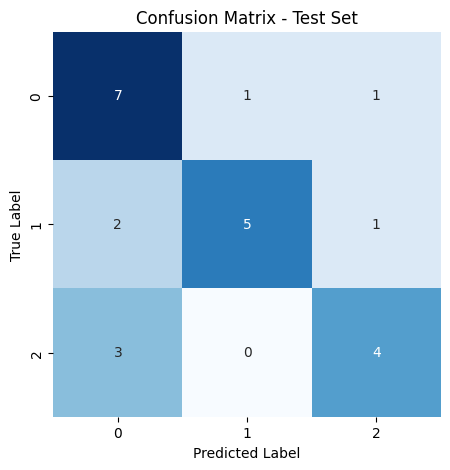

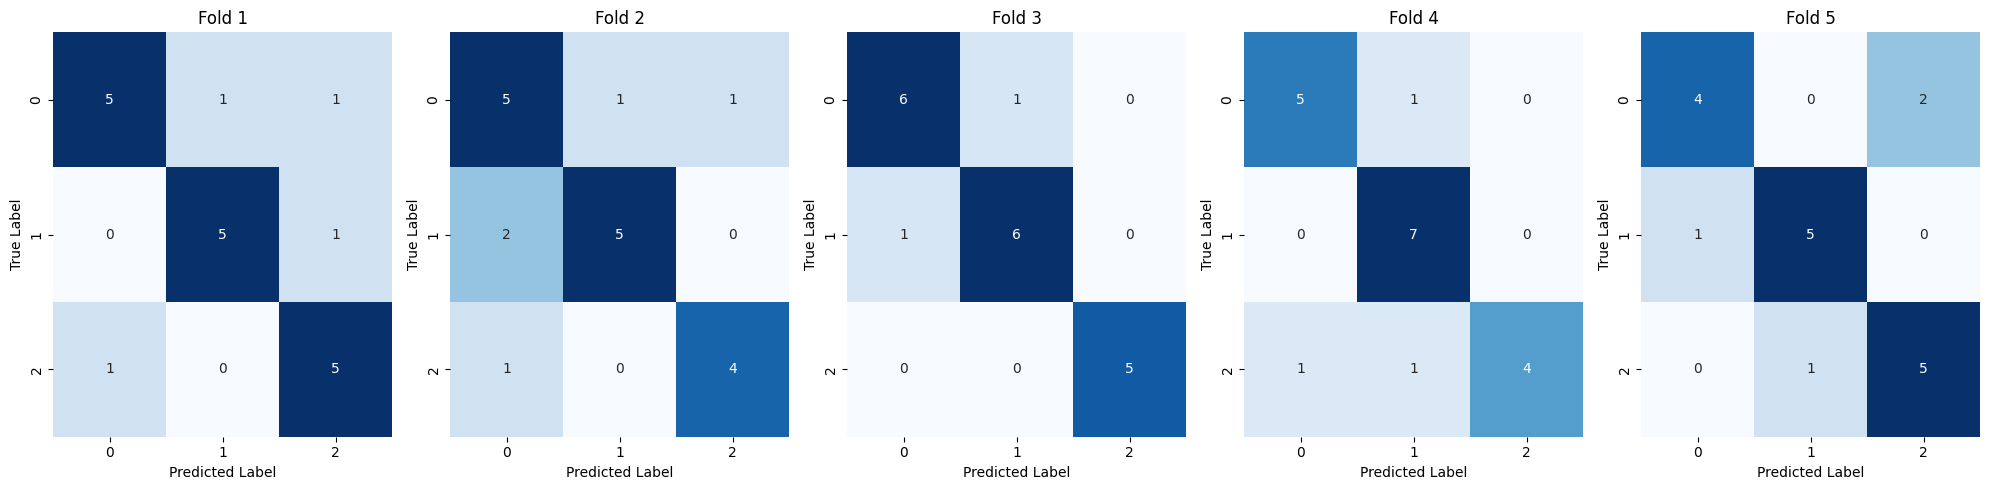

In [3]:
#calling important libraries

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

icpms = pd.read_excel('/content/dataset icpms(1).xlsx',
                      sheet_name='icpms')
icpms.dtypes

icpms['T'] = icpms['T'].astype(float)

#############################################################################################


#for splitting the dataframes

from sklearn.model_selection import (train_test_split,
                                     StratifiedKFold,
                                     cross_val_score)

# for calling the models

from sklearn.ensemble import GradientBoostingClassifier


#for calling the model performance metrics
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix,
                             precision_score,
                             recall_score,
                             f1_score)

###################################################################################################


from sklearn.model_selection import train_test_split

# Separate features (X) and target label (y)

# Defining the dataframe into X features and y target label

X = icpms.drop(columns=['T'])
y = icpms['T']



# Split into training and testing sets in a stratified manner

#for splitting the dataframes

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,

                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.

                                                    random_state=42)


# Check the distribution of target labels in the train and test sets
train_distribution = y_train.value_counts(normalize=True)

test_distribution = y_test.value_counts(normalize=True)

train_distribution, test_distribution



######################################################################################################################################################################################################



# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


#########################################################################################


# Function to train and evaluate the model

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):

    # Initialize the Gradient Boosting Classifier

    gb_model = GradientBoostingClassifier(random_state=42)

    gb_model.fit(X_train_fold, y_train_fold)

    y_val_pred = gb_model.predict(X_val_fold)

    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, gb_model

###########################################################################################


# Store fold metrics
fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': [],
    'roc_curves': [],
    'auc_scores': []
}
best_model = None
best_accuracy = 0

# Cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate additional metrics
    y_val_pred = model.predict(X_val_fold)
    y_val_prob = model.predict_proba(X_val_fold)[:, 1] if len(model.classes_) == 2 else None
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)


    if y_val_prob is not None:
        fpr, tpr, _ = roc_curve(y_val_fold, y_val_prob)
        auc_score = roc_auc_score(y_val_fold, y_val_prob)
        fold_metrics['roc_curves'].append((fpr, tpr))
        fold_metrics['auc_scores'].append(auc_score)


    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

    if y_val_prob is not None:
        print(f"  AUC Score: {auc_score:.4f}")

# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])
avg_auc_score = np.mean(fold_metrics['auc_scores']) if fold_metrics['auc_scores'] else None



print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")
if avg_auc_score is not None:
    print(f"  Average AUC Score: {avg_auc_score:.4f}")


# Plot Metrics
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()

# Confusion Matrix Visualization
for fold, confusion in enumerate(fold_metrics['confusion_matrices'], start=1):
    plt.figure(figsize=(5, 5))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

# Test set Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



############################################################################################



import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion Matrix Visualization as Subplots
fig, axes = plt.subplots(1, len(fold_metrics['confusion_matrices']), figsize=(20, 5))

for fold, (confusion, ax) in enumerate(zip(fold_metrics['confusion_matrices'], axes), start=1):

    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

    ax.set_title(f'Fold {fold}')

    ax.set_xlabel('Predicted Label')

    ax.set_ylabel('True Label')

plt.tight_layout()

plt.show()

#####################################################################################

# ROC Curve Visualization
if fold_metrics['roc_curves']:
    plt.figure(figsize=(10, 6))
    for fold, (fpr, tpr) in enumerate(fold_metrics['roc_curves'], start=1):
        plt.plot(fpr, tpr, label=f'Fold {fold} (AUC = {fold_metrics["auc_scores"][fold - 1]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Across Folds')
    plt.legend()
    plt.show()


y_test_prob = best_model.predict_proba(X_test)[:, 1] if len(best_model.classes_) == 2 else None


# Test ROC Curve
if y_test_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test ROC Curve')
    plt.legend()
    plt.show()


#**support vector machines**

Fold 1 Metrics:
  Accuracy: 0.8421
  Precision: 0.8628
  Recall: 0.8421
  F1-Score: 0.8389
Fold 2 Metrics:
  Accuracy: 0.6316
  Precision: 0.6667
  Recall: 0.6316
  F1-Score: 0.6317
Fold 3 Metrics:
  Accuracy: 0.7895
  Precision: 0.8660
  Recall: 0.7895
  F1-Score: 0.7909
Fold 4 Metrics:
  Accuracy: 0.8421
  Precision: 0.8466
  Recall: 0.8421
  F1-Score: 0.8410
Fold 5 Metrics:
  Accuracy: 0.6667
  Precision: 0.7667
  Recall: 0.6667
  F1-Score: 0.6730

Average Metrics Across All Folds:
  Accuracy: 0.7544
  Precision: 0.8018
  Recall: 0.7544
  F1-Score: 0.7551

Test Set Metrics:
  Accuracy: 0.8333
  Precision: 0.8394
  Recall: 0.8333
  F1-Score: 0.8278


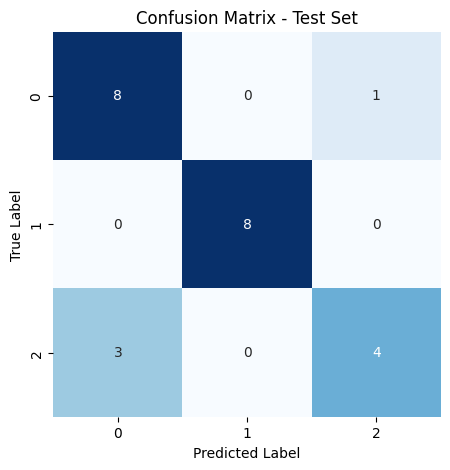

In [4]:
# Support vector classifier

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Dataset preparation

# Assuming epma2_df is already loaded
X = icpms.drop(columns=['T'])  # Drop target and non-feature columns
y = icpms['T']



# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):

    # Initialize the SVM Classifier
    svm_model = SVC(kernel='rbf',
                    probability=True,
                    random_state=42)

    # Fit the model
    svm_model.fit(X_train_fold, y_train_fold)

    # Predict on validation set
    y_val_pred = svm_model.predict(X_val_fold)

    # Calculate accuracy
    accuracy = accuracy_score(y_val_fold,
                              y_val_pred)

    return accuracy, svm_model

# Cross-validation
fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': [],
    'roc_curves': [],
    'auc_scores': []
}

best_model = None
best_accuracy = 0

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate additional metrics
    y_val_pred = model.predict(X_val_fold)
    y_val_prob = model.predict_proba(X_val_fold)[:, 1] if len(model.classes_) == 2 else None
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    if y_val_prob is not None:
        fpr, tpr, _ = roc_curve(y_val_fold, y_val_prob)
        auc_score = roc_auc_score(y_val_fold, y_val_prob)
        fold_metrics['roc_curves'].append((fpr, tpr))
        fold_metrics['auc_scores'].append(auc_score)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    if y_val_prob is not None:
        print(f"  AUC Score: {auc_score:.4f}")

# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])
avg_auc_score = np.mean(fold_metrics['auc_scores']) if fold_metrics['auc_scores'] else None

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")
if avg_auc_score is not None:
    print(f"  Average AUC Score: {avg_auc_score:.4f}")



# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
y_test_prob = best_model.predict_proba(X_test)[:, 1] if len(best_model.classes_) == 2 else None
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

test_auc = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
if test_auc is not None:
    print(f"  AUC Score: {test_auc:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Test ROC Curve
if y_test_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test ROC Curve')
    plt.legend()
    plt.show()

###############################################################################################################




#**ensemble model 3 gradient booster and support vector**

Ensemble Model Accuracy: 0.83

Confusion Matrix:

[[7 0 2]
 [0 8 0]
 [2 0 5]]


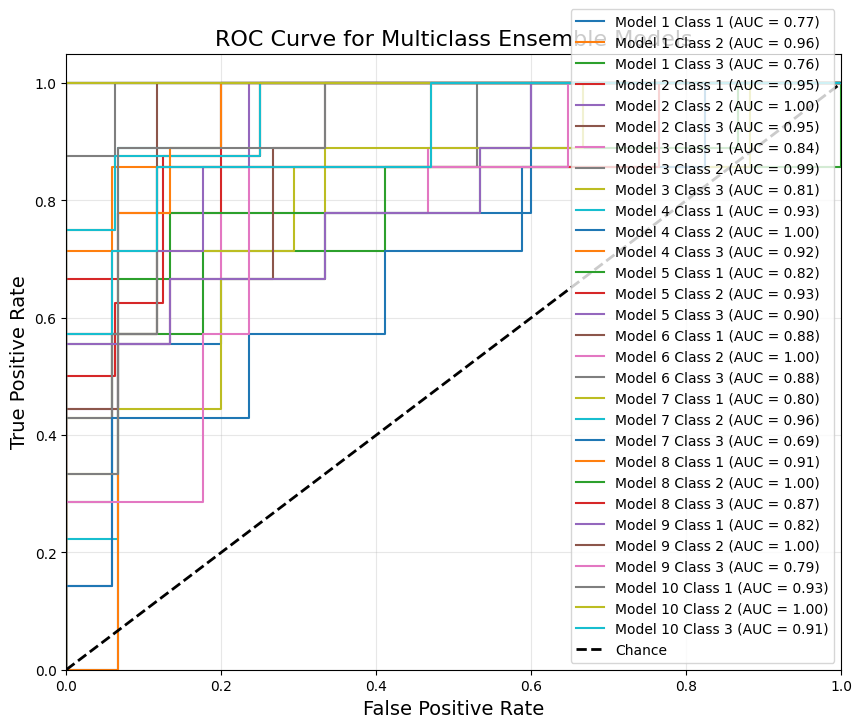

In [5]:
#ensemble model 3 gradient booster and support vector machines

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt


# Assuming epma2 is a DataFrame with target label 'T'

# Split the dataset into features (X) and target (y)
X = icpms.drop(columns=['T'])
y = icpms['T']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize base models
base_gbc = GradientBoostingClassifier(random_state=42)
base_svc = SVC(probability=True, random_state=42)

# Number of bootstrap samples
n_bootstrap = 5

# Initialize lists to store models
models = []

# Bootstrap sampling and model training
for i in range(n_bootstrap):
    # Create a bootstrap sample
    X_bootstrap, y_bootstrap = resample(X_train, y_train, random_state=i)

    # Train Gradient Boosting Classifier
    gbc = GradientBoostingClassifier(n_estimators=110,
                                     learning_rate=0.02,
                                     max_depth=4,
                                     subsample=0.9,
                                     random_state=i)
    gbc.fit(X_bootstrap, y_bootstrap)
    models.append(gbc)

    # Train SVM Classifier
    svc = SVC(probability=True,
              C=10,
              kernel='rbf',
              gamma='scale',
              random_state=i)

    svc.fit(X_bootstrap, y_bootstrap)
    models.append(svc)

# Max voting prediction
def max_voting(models, X_test):
    predictions = np.array([model.predict(X_test) for model in models]).T
    final_predictions = [Counter(row).most_common(1)[0][0] for row in predictions]
    return final_predictions

# Perform max voting
final_predictions = max_voting(models, X_test)

# Evaluate the ensemble model
accuracy = accuracy_score(y_test, final_predictions)
print(f"Ensemble Model Accuracy: {accuracy:.2f}")


################################################################################################################################

from sklearn.preprocessing import label_binarize
# Confusion matrix
conf_matrix = confusion_matrix(y_test, final_predictions)
print("\nConfusion Matrix:\n")
print(conf_matrix)

# ROC Curve for Multiclass
# ROC Curve for Multiclass

from sklearn.preprocessing import label_binarize
if len(np.unique(y)) > 2:
  y_test_binarized = label_binarize(y_test, classes=np.unique(y))
  plt.figure(figsize=(10, 8))
  for i, model in enumerate(models):
    if hasattr(model, "predict_proba"):
      y_proba = model.predict_proba(X_test)

    else:
      continue  # Skip models without probability prediction
    for j in range(y_test_binarized.shape[1]):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, j], y_proba[:, j])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Model {i+1} Class {j+1} (AUC = {roc_auc:.2f})")
  plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Chance")
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel("False Positive Rate", fontsize=14)
  plt.ylabel("True Positive Rate", fontsize=14)
  plt.title("ROC Curve for Multiclass Ensemble Models", fontsize=16)
  plt.legend(loc="lower right", fontsize=10)
  plt.grid(alpha=0.3)
  plt.show()
else:
  # Plot ROC Curve for Binary Classification
        plt.figure(figsize=(10, 8))
        for i, model in enumerate(models):
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test)[:, 1]
            else:
                y_proba = model.decision_function(X_test)
                y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())  # Normalize scores
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Model {i+1} (AUC = {roc_auc:.2f})")

        plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Chance")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate", fontsize=14)
        plt.ylabel("True Positive Rate", fontsize=14)
        plt.title("ROC Curve of Ensemble Models", fontsize=16)
        plt.legend(loc="lower right", fontsize=12)
        plt.grid(alpha=0.3)
        plt.show()

        '''
except ImportError as e:
  print("Error with ROC curve plotting:", e)
'''
